# This notebook is going to contain my attempt to predict the decision made based off of the sensor data

-- File sensor_readings_4.data:<br> 
1. SD_front: minimum sensor reading within a 60 degree arc located at the front of the robot - (numeric: real)<br>
2. SD_left:  minimum sensor reading within a 60 degree arc located at the left of the robot  - (numeric: real)<br>
3. SD_right: minimum sensor reading within a 60 degree arc located at the right of the robot - (numeric: real)<br>
4. SD_back:  minimum sensor reading within a 60 degree arc located at the back of the robot - (numeric: real)<br>
5. Class: <br>
  		-- Move-Forward
  		-- Slight-Right-Turn
  		-- Sharp-Right-Turn
  		-- Slight-Left-Turn




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

dataframe = pd.read_csv('sensor_readings_4.csv')

fig, axes = plt.subplots(4, 2, figsize=(12, 10))

x = dataframe.index
y1 = dataframe['front']
y2 = dataframe['left']
y3 = dataframe['right']
y4 = dataframe['back']
axes[0,0].plot(x, y1, label='front')
axes[0,0].plot(x, y2, label='left')
axes[0,0].plot(x, y3, label='right')
axes[0,0].plot(x, y4, label='back')
axes[0,0].set_xlabel('Index')
axes[0,0].set_ylabel('Raw Sensor Reading')
axes[0,0].legend()

axes[0,1].plot(x, y1, label='front')
axes[0,1].set_xlabel('Index')
axes[0,1].set_ylabel('Raw Sensor Reading')
axes[0,1].legend()

axes[1,0].plot(x, y2, label='left')
axes[1,0].set_xlabel('Index')
axes[1,0].set_ylabel('Raw Sensor Reading')
axes[1,0].legend()

axes[1,1].plot(x, y3, label='right')
axes[1,1].set_xlabel('Index')
axes[1,1].set_ylabel('Raw Sensor Reading')
axes[1,1].legend()

axes[2,0].plot(x, y4, label='back')
axes[2,0].set_xlabel('Index')
axes[2,0].set_ylabel('Raw Sensor Reading')
axes[2,0].legend()

axes[2,1].plot

plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

dataframe = pd.read_csv('sensor_readings_4.csv')

print(dataframe.head())


for row in dataframe.itertuples():
    max_col_value = dataframe.loc[row.Index, ['front', 'left', 'right']].idxmax()
    print(f"Row {row.Index}: Max value is {max_col_value} and actual label is {row.label}")

1.0


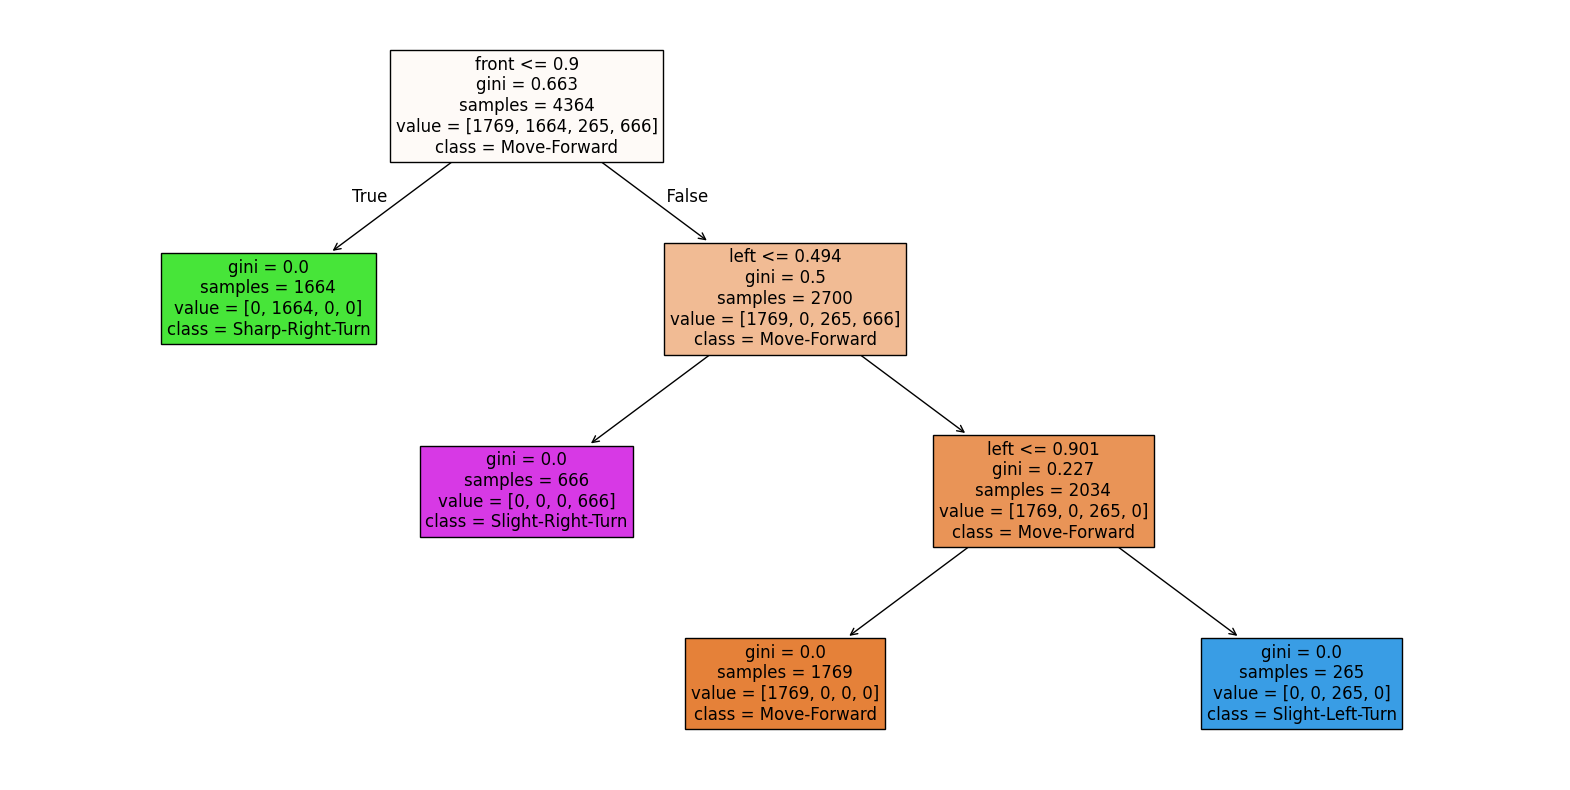

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

dataframe = pd.read_csv('sensor_readings_4.csv')

sensor_data = dataframe[['front', 'left', 'right', 'back']]

results = dataframe[['label']]

#print(sensor_data)
#print(results)

x_train, x_test, y_train, y_test = train_test_split(sensor_data, results, test_size=0.20, random_state=33)

#print(x_train)
#print(y_train)
#print(x_test)
#print(y_test)

classifier = DecisionTreeClassifier(max_depth=3).fit(x_train, y_train)
precictions = classifier.predict(x_test)
score = accuracy_score(y_test, precictions)

print(score)

plt.figure(figsize=(20, 10))
plot_tree(classifier, feature_names=sensor_data.columns, class_names=classifier.classes_, filled=True, fontsize=12)
plt.show()

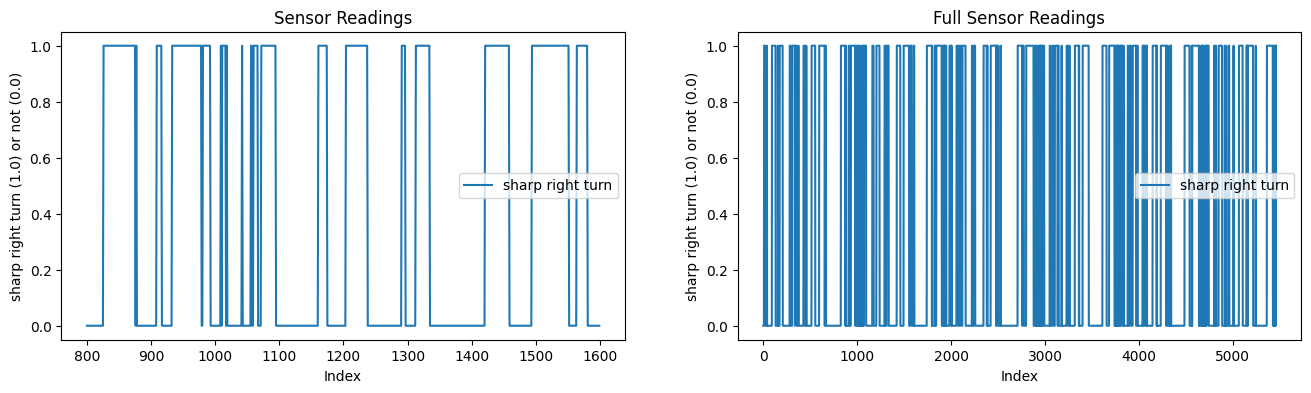

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

dataframe = pd.read_csv('sensor_readings_4.csv')

results = dataframe[['label']]

floats = []

for index, row in results.iterrows():
    if row['label'] == "Sharp-Right-Turn":
        floats.append(1.0)
    else:
        floats.append(0.0)

results['label'] = floats

segment = results.iloc[800:1600]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))


x = segment.index
y = segment['label']

x2 = results.index
y2 = results['label']

axes[0].plot(x, y, label='sharp right turn')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('sharp right turn (1.0) or not (0.0)')
axes[0].set_title('Sensor Readings')
axes[0].legend()

axes[1].plot(x2, y2, label='sharp right turn')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('sharp right turn (1.0) or not (0.0)')
axes[1].set_title('Full Sensor Readings')
axes[1].legend()

plt.show()

Intuitively I beleived that the first value that would be checked would be the foward sensor to see if there is space in front of it to pathfind into, then it would check for any danger and course correct with the left and right sensors.  

However the decision tree reveals that the robot first checks the front sensor to see if there is an obstacle in front of it. If there is then it preforms a sharp right turn. 

Then it checks it checks the left sensor, if the left sensor is extremely close(<=0.494) then there is a slight right turn, and if it within a certain margin(0.494-0.901) it moves foward. 

if the left sensor was large(>0.901) it would go slightly left

This leads me to conclude that the robot was effectively hugging the wall balancing a certain distance between it and the robot (0.494-0.901) and checking to make sure the front is not about to collide, and that it is not veering to far from the left wall. 

Looking at the frequency of sharp right turns over the interval it is resoanable to assume that the wall creates a loop and the data shows 6 repitions, there is also 8 plateaus which are irregular however may indicate an 8 angled shape being followed

The low amount of slight left turns and absence of sharp left turns leads me to conclude that the path/wall is possibly a 6-10 sided that the robot was moving clockwise in, using wall following. 

In [117]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
